In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1)

Разрешение изображения:  (256, 256)


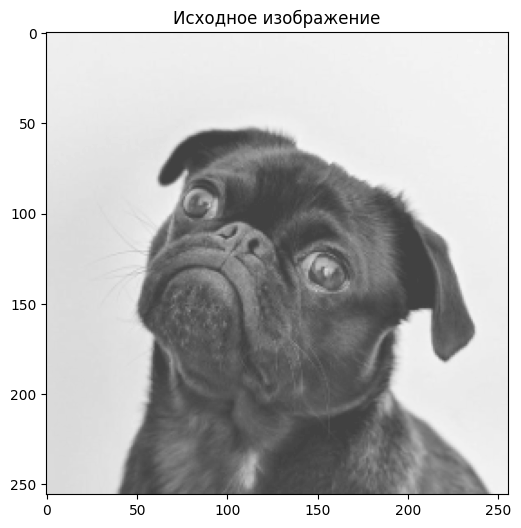

In [2]:
pic = plt.imread("dog.png")

if len(pic.shape) == 3:
    pic = np.mean(pic, axis=2)

if pic.dtype != np.uint8:
    pic = (pic * 255).astype(np.uint8)

plt.figure(figsize=(12,6))
print("Разрешение изображения: ", pic.shape)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное изображение")
plt.show()

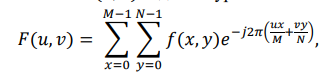

In [3]:
def FFT_2d(pic):
    fft_rows = np.fft.fft(pic, axis=0)
    
    fft_2d = np.fft.fft(fft_rows, axis=1)
    return fft_2d


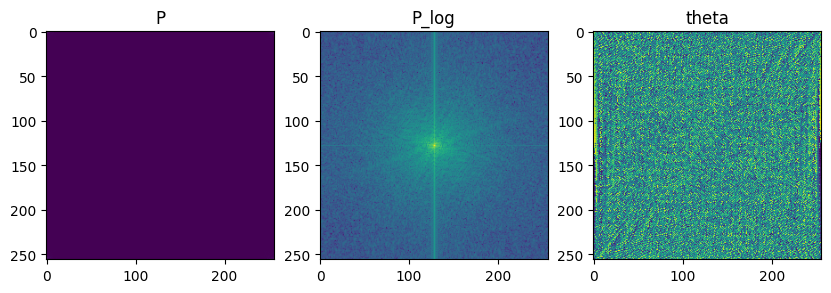

In [29]:
fft = FFT_2d(pic)

P = np.abs(fft)  
theta = np.angle(fft)  
   
P_log = np.log(1 + P)

plt.figure(figsize=(10,10))
plt.subplot(1,3,1)
plt.imshow(P)
plt.title("P")


plt.subplot(1,3,2)
plt.imshow(np.fft.fftshift(P_log))
plt.title("P_log")

plt.subplot(1,3,3)
plt.imshow(theta)
plt.title("theta")
plt.show()

### 2) 

In [5]:
def IFFT_1d(fft_2d, x,y):
    tmp = 0
    for u in range(fft_2d.shape[0]):
        for v in range(fft_2d.shape[1]):
            tmp+= fft_2d[u][v] * np.exp(1j * 2 * np.pi *(u*x/fft_2d.shape[0] + y*v/fft_2d.shape[1]))

    return tmp
            

def IFFT_2d_old(fft_2d):
    new_pic = np.zeros((fft_2d.shape[0],fft_2d.shape[1]))

    for x in range(fft_2d.shape[0]):
        for y in range(fft_2d.shape[1]):
            new_pic[x][y] = 1/(fft_2d.shape[0] * fft_2d.shape[1]) * IFFT_1d(fft_2d, x,y)

    return new_pic

In [6]:
def IFFT_2d(fft_2d):
    
    M, N = fft_2d.shape
    result = np.zeros((M, N), dtype=complex)
    u = np.arange(M).reshape(M, 1)
    v = np.arange(N).reshape(1, N)
            

    for x in range(M):
        for y in range(N):
            
            exponent = 1j * 2 * np.pi * (u * x / M + v * y / N)
            result[x, y] = np.sum(fft_2d * np.exp(exponent))
    
    return result / (M * N)

In [7]:
PIC = IFFT_2d(fft)

In [8]:
PIC

array([[238.-1.77635684e-15j, 238.-1.24344979e-14j, 238.+7.10542736e-15j,
        ..., 244.-7.90478794e-14j, 244.-1.22124533e-13j,
        244.-1.24344979e-13j],
       [239.-8.88178420e-15j, 239.-2.48689958e-14j, 239.+3.55271368e-14j,
        ..., 244.-7.58060281e-13j, 244.-7.37188088e-14j,
        243.-1.39444012e-13j],
       [239.-7.10542736e-15j, 239.-1.42108547e-14j, 239.+5.32907052e-15j,
        ..., 244.-1.96109795e-12j, 244.-3.75299791e-12j,
        243.-2.77999845e-13j],
       ...,
       [219.+9.76996262e-14j, 218.+1.88649096e-12j, 218.-1.89892546e-12j,
        ..., 242.-5.71453995e-12j, 241.-4.68247663e-12j,
        241.-1.36823886e-12j],
       [219.+1.47437618e-13j, 218.+5.20472554e-13j, 218.+3.44613227e-13j,
        ..., 242.-5.36504174e-12j, 241.-7.81996690e-12j,
        241.-3.71080944e-12j],
       [219.+2.00728323e-13j, 218.+2.09965378e-12j, 218.+3.06776826e-12j,
        ..., 242.-5.49782442e-12j, 241.-6.36068975e-12j,
        242.-5.75939296e-12j]])

In [9]:
res = np.real(PIC)
error_map = pic - res

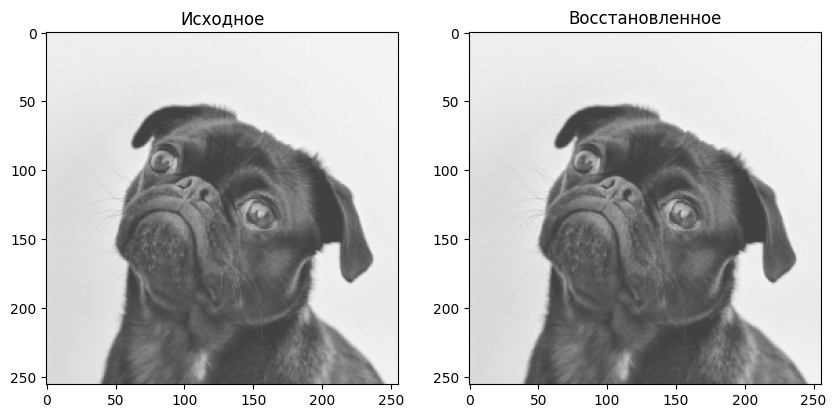

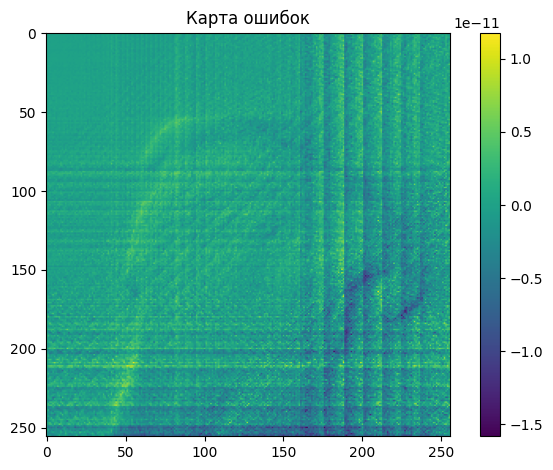

In [10]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(res, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()


plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

### 3)

#### a)

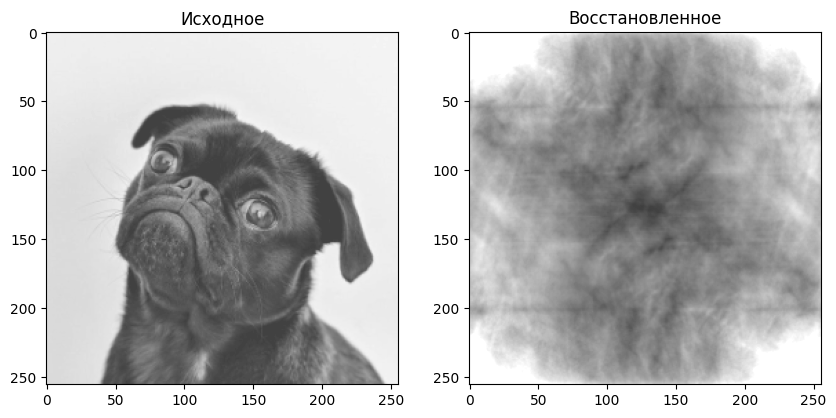

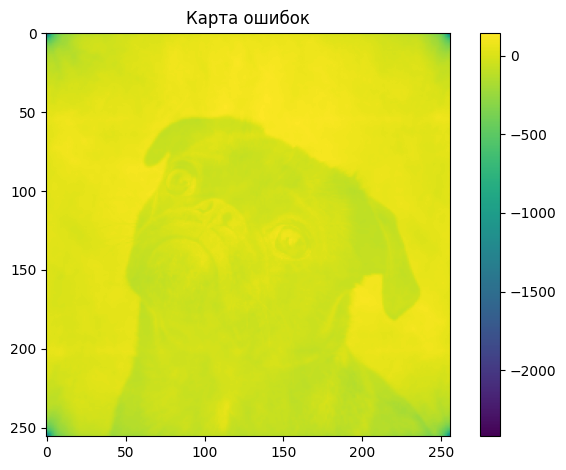

In [11]:
def simple_zero_phase_demo(pic):
    fft_spectrum = np.fft.fft2(pic)
    
    amplitudes = np.abs(fft_spectrum)
    

    fft_zero_phase = np.real(amplitudes).astype(complex)*np.exp(1j*0)

    
    restored = np.real(np.fft.ifft2(fft_zero_phase))

    return restored

n_pic = simple_zero_phase_demo(pic)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(n_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()

error_map = pic - n_pic
plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

#### b)

In [27]:
def amplitude_one(pic):
    fft_spectrum = np.fft.fft2(pic)
    apl = np.abs(fft_spectrum)
    phs = np.angle(fft_spectrum)

    apl_1 = apl.copy()
    apl_1[:,:] = 1
    new_fft = np.real(apl_1)*np.exp(1j*phs)

    new_pic = np.fft.ifft2(new_fft)


    return np.real(new_pic)

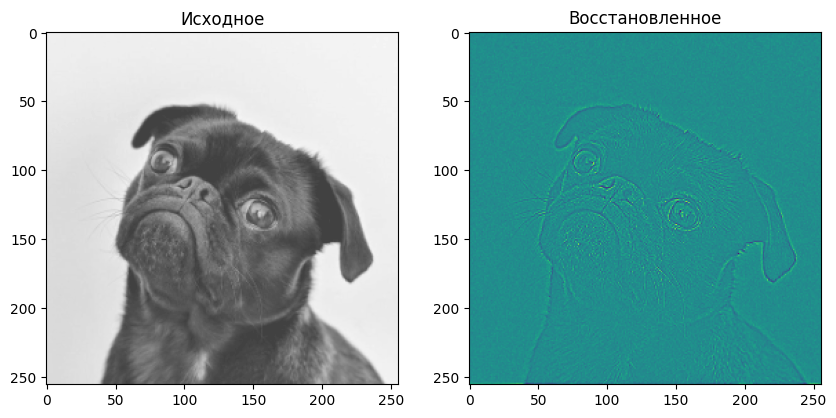

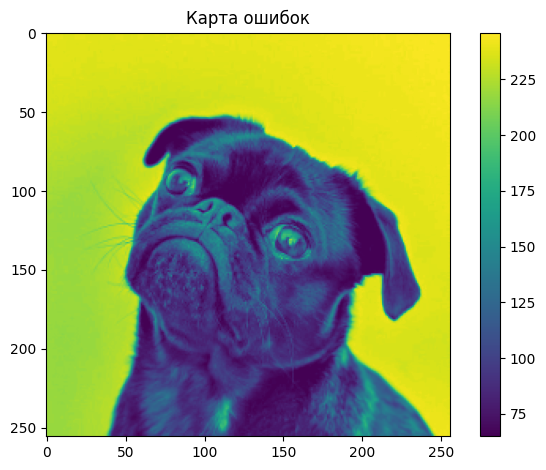

In [28]:
one_pic = amplitude_one(pic)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(one_pic)
plt.title("Восстановленное")
plt.show()

error_map = pic - one_pic
plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

In [14]:
one_pic

array([[ 0.        ,  0.00379108,  0.01376335, ..., -0.00262048,
        -0.01376335, -0.00379108],
       [-0.00844077, -0.0199564 , -0.02571435, ..., -0.01366249,
        -0.01159533, -0.00480032],
       [ 0.00200855, -0.00271346,  0.00683698, ...,  0.0022968 ,
         0.01243181, -0.00213572],
       ...,
       [-0.00584534,  0.00259096,  0.01094017, ..., -0.00631153,
         0.00774397,  0.02003326],
       [-0.00200855,  0.00213572, -0.01243181, ...,  0.00270586,
        -0.00683698,  0.00271346],
       [ 0.00844077,  0.00480032,  0.01159533, ...,  0.00023512,
         0.02571435,  0.0199564 ]])

### 4)

#### a)

In [15]:
def fft_central(pic, n):

    K = 3*n
    fft_pic = np.fft.fft2(pic)
    fft_shifted = np.fft.fftshift(fft_pic)
    fft_modified = fft_shifted.copy()
    
    rows, cols = fft_shifted.shape
    center_row, center_col = rows // 2, cols // 2
    
    for row in range(rows):
        for col in range(cols):
            distance = np.sqrt((row - center_row)**2 + (col - center_col)**2)
            if distance > K:
                fft_modified[row, col] = 0
    
    fft_ishifted = np.fft.ifftshift(fft_modified)
    new_pic = np.fft.ifft2(fft_ishifted)
    
    return np.real(new_pic), fft_modified
    

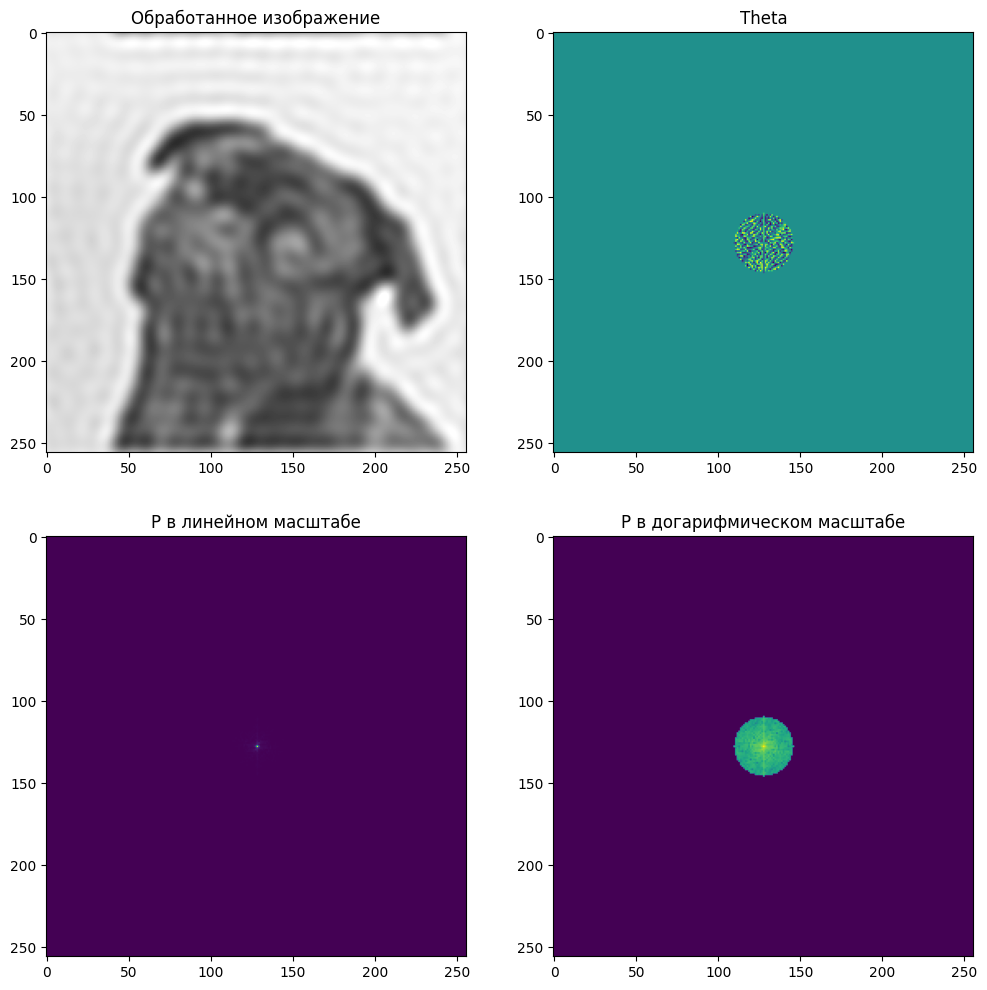

In [16]:
new_pic, fft_central_pic= fft_central(pic, 6)

plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.imshow(new_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Обработанное изображение")

plt.subplot(2,2,3)
plt.imshow(np.abs(fft_central_pic))
plt.title("P в линейном масштабе")

plt.subplot(2,2,4)
plt.imshow(np.log2(1+np.abs(fft_central_pic)))
plt.title("P в догарифмическом масштабе")


plt.subplot(2,2,2)
plt.imshow(np.angle(fft_central_pic))
plt.title("Theta")


plt.show()

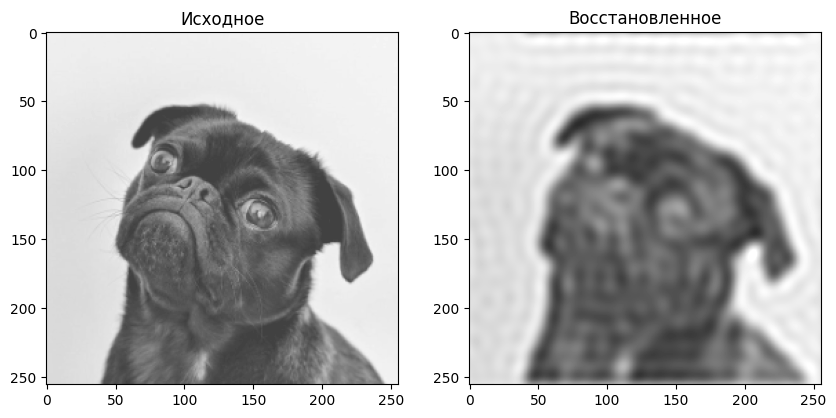

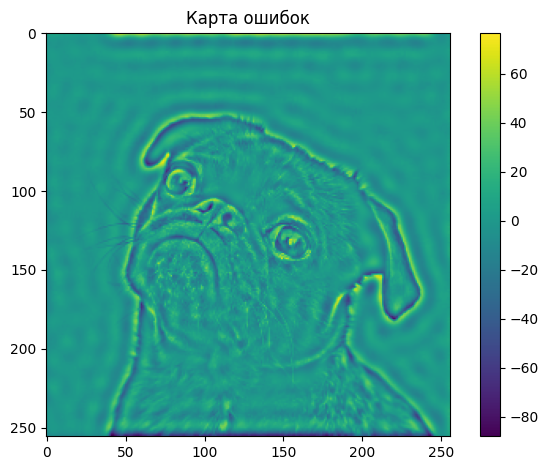

In [17]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(new_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Восстановленное")
plt.show()

error_map = pic - new_pic
plt.imshow(error_map)
plt.colorbar()
plt.title("Карта ошибок")
plt.tight_layout()

plt.show()

#### b)
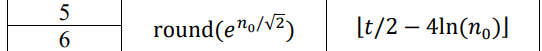

In [18]:
def fft_bublik(pic, n):

    t = min(pic.shape)  
    K1 = np.round(np.exp(n/np.sqrt(2)))
    K2 = np.floor(t/2 - 4*np.log(n))
    fft_pic = np.fft.fft2(pic)
    fft_shifted = np.fft.fftshift(fft_pic)
    fft_modified = fft_shifted.copy()
    
    rows, cols = fft_shifted.shape
    center_row, center_col = rows // 2, cols // 2
    
    for row in range(rows):
        for col in range(cols):
            distance = np.sqrt((row - center_row)**2 + (col - center_col)**2)
            if distance< K1 or distance>K2:
                fft_modified[row, col] = 0
    
    fft_ishifted = np.fft.ifftshift(fft_modified)
    new_pic = np.fft.ifft2(fft_ishifted)
    
    return np.real(new_pic).astype(np.uint8), fft_modified

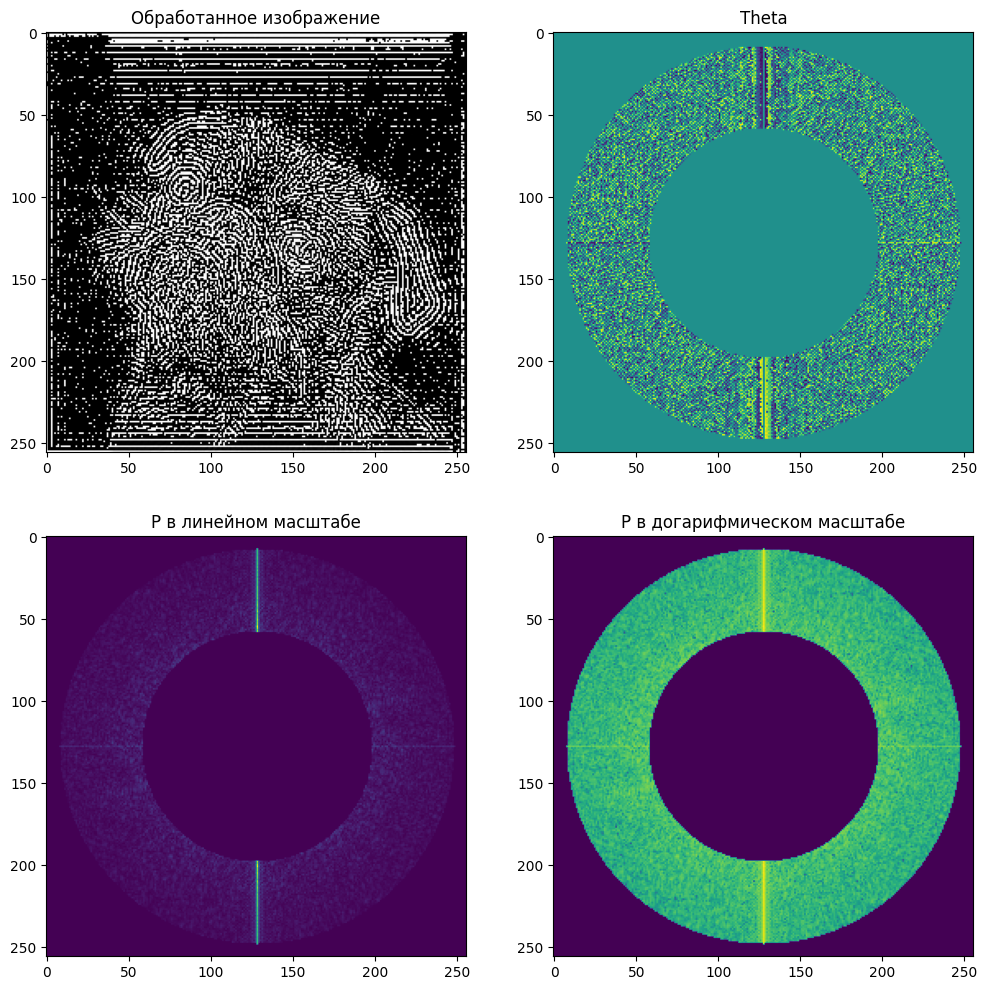

In [19]:
new_pic, fft_pic= fft_bublik(pic, 6)

plt.figure(figsize=(12,12))
plt.subplot(2,2,1)
plt.imshow(new_pic, cmap='gray',vmin=0,vmax=255)
plt.title("Обработанное изображение")

plt.subplot(2,2,3)
plt.imshow(np.abs(fft_pic))
plt.title("P в линейном масштабе")

plt.subplot(2,2,4)
plt.imshow(np.log2(1+np.abs(fft_pic)))
plt.title("P в догарифмическом масштабе")


plt.subplot(2,2,2)
plt.imshow(np.angle(fft_pic))
plt.title("Theta")


plt.show()

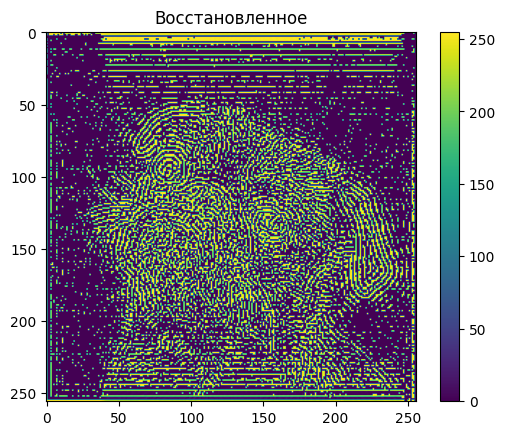

In [20]:
plt.imshow(new_pic)
plt.title("Восстановленное")
plt.colorbar()
plt.show()



### 5)
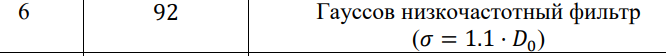

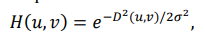

In [21]:
def filter_H(pic, D0, sigma_factor=1.1):
    rows, cols = pic.shape
    center_row, center_col = rows // 2, cols // 2
    
    u = np.arange(cols) - center_col
    v = np.arange(rows) - center_row
    U, V = np.meshgrid(u, v)
    
    D = np.sqrt(U**2 + V**2)

    sigma = sigma_factor * D0
    
    H_lp = np.exp(-D**2 / (2 * sigma**2))
    
    H_hp = 1 - H_lp
    
    return H_hp

### 6)

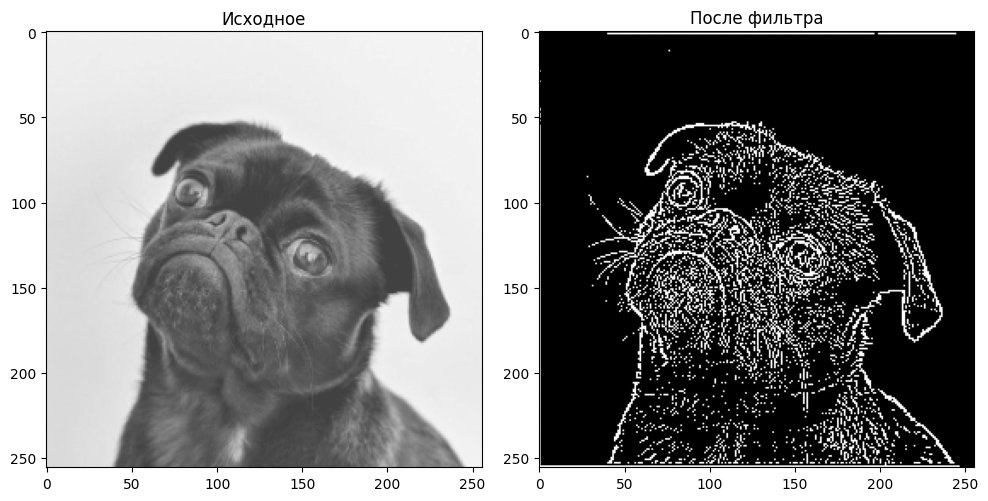

In [22]:
fft_pic = np.fft.fft2(pic)
fft_shift = np.fft.fftshift(fft_pic)

D0 = 92
H_hp = filter_H(pic, D0)

filtered_fft = fft_shift * H_hp

filtered_fft_ishifted = np.fft.ifftshift(filtered_fft)
new_pic = np.real(np.fft.ifft2(filtered_fft_ishifted)).astype(np.uint8)



plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(new_pic,cmap='gray',vmin=0,vmax=255)
plt.title("После фильтра")

plt.tight_layout()
plt.show()



In [23]:
def gistogramm(pic, V_min=0, V_max=255):
    gistogramm_dict = {}
    
    for value in range(V_min, V_max + 1):
        gistogramm_dict[value] = 0
    
    for row in range(len(pic)):
        for col in range(len(pic[0])):
            pixel_value = pic[row][col]
            if V_min <= pixel_value <= V_max:
                gistogramm_dict[pixel_value] += 1
    
    return gistogramm_dict

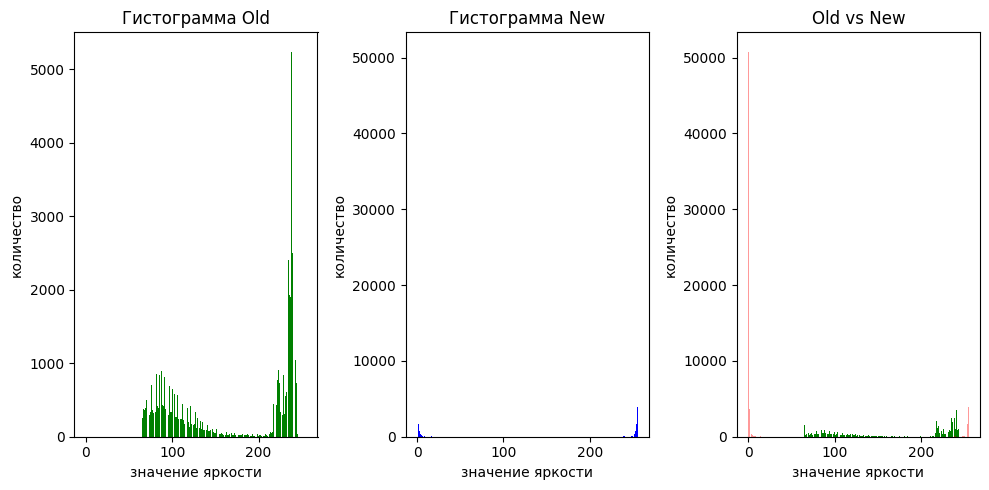

In [24]:


gist_old = gistogramm(pic)
gist_new = gistogramm(new_pic)

value_old = gist_old.keys()
cnt_old = gist_old.values()

value_new = gist_new.keys()
cnt_new = gist_new.values()

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.bar(value_old, cnt_old, color='g')
plt.xlabel('значение яркости')
plt.ylabel('количество')

plt.title('Гистограмма Old')

plt.subplot(1,3,2)
plt.bar(value_new, cnt_new, color='b')
plt.xlabel('значение яркости')
plt.ylabel('количество')
plt.title('Гистограмма New')

plt.subplot(1,3,3)
plt.bar(value_old, cnt_old, color='g')
plt.bar(value_new, cnt_new, color='r', alpha=0.4)
plt.xlabel('значение яркости')
plt.ylabel('количество')
plt.title('Old vs New')
plt.tight_layout()
plt.show()

### 7)

In [25]:
def power_h_filter(pic,a ,b):
    fft_pic = np.fft.fft2(pic)
    fft_shift = np.fft.fftshift(fft_pic)

    D0 = 92
    H_hp = filter_H(pic, D0)

    power_H_hp = a + b*H_hp
    filtered_fft = fft_shift * power_H_hp

    filtered_fft_ishifted = np.fft.ifftshift(filtered_fft)
    new_pic = np.real(np.fft.ifft2(filtered_fft_ishifted)).astype(np.uint8)

    return new_pic

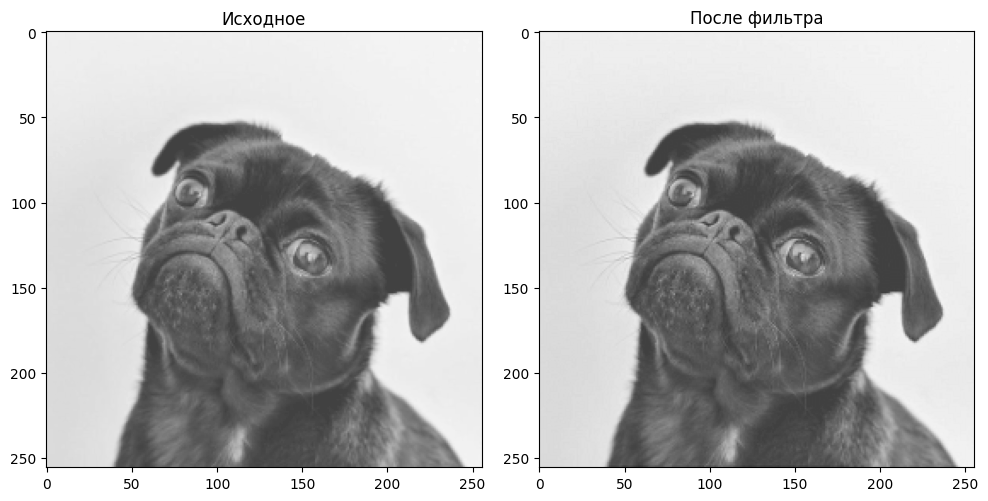

In [26]:
new_pic = power_h_filter(pic,1,0.5)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(pic, cmap='gray',vmin=0,vmax=255)
plt.title("Исходное")

plt.subplot(1,2,2)
plt.imshow(new_pic,cmap='gray',vmin=0,vmax=255)
plt.title("После фильтра")

plt.tight_layout()
plt.show()